# Acoustic Uroflowmetry Prototype
Estimate urinary flow rate from sound using DSP features and super vised ML models to estimate new measures.

Pipeline:
1. Calibration from known flows
2. Feature extraction (MFCC + spectral features) with Digital Signal Processing
3. RMS-based segmentation
4. KNN similarity to estimate flow per segment
5. Plot uroflow curve


In [54]:
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

import operator

from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# from sklearn.ensemble import RandomForestClassifier

import glob
import os

from scipy.signal import butter, lfilter




## Feature Extraction

In [55]:
def extract_features(y, sr):

    # -------------------------
    # 0️⃣ Pré-traitement robuste micro
    # -------------------------
    
    # Enlève les très basses fréquences (bruits de pièce)
    # y = librosa.effects.preemphasis(y)

    # =========================
    # 1️⃣ MFCC (texture globale)
    # =========================
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13,
        n_fft=2048,
        hop_length=512
    )

    # Normalisation cepstrale (CMVN) : stabilise les MFCC entre micros
    # mfcc = (mfcc - np.mean(mfcc, axis=1, keepdims=True)) / \
    #        (np.std(mfcc, axis=1, keepdims=True) + 1e-8)

    # mfcc = mfcc - np.mean(mfcc, axis=1, keepdims=True)

    features = []
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))

    # =========================
    # 2️⃣ Features spectrales
    # =========================
    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features.append(np.mean(spec_centroid))
    features.append(np.std(spec_centroid))

    spec_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features.append(np.mean(spec_bandwidth))
    features.append(np.std(spec_bandwidth))

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
    features.append(np.mean(rolloff))
    features.append(np.std(rolloff))

    # =========================
    # 3️⃣ Bruit vs tonal
    # =========================
    spec_flatness = librosa.feature.spectral_flatness(y=y)
    features.append(np.mean(spec_flatness))
    features.append(np.std(spec_flatness))

    # =========================
    # 4️⃣ Dynamique / énergie
    # =========================
    rms = librosa.feature.rms(y=y)
    features.append(np.mean(rms))
    features.append(np.std(rms))

    # =========================
    # 5️⃣ Rugosité temporelle
    # =========================
    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))
    features.append(np.std(zcr))

    # =========================
    # 6️⃣ Flux spectral (variation du spectre dans le temps)
    # Très corrélé aux turbulences et donc au débit
    # Plus le flux est élevé, plus le jet est turbulent / intense
    # =========================
    # Calcul du spectrogramme magnitude
    S = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))
    # Flux spectral : différence entre frames successives
    flux = np.sqrt(np.sum(np.diff(S, axis=1)**2, axis=0)) / S.shape[0]
    features.append(np.mean(flux))
    features.append(np.std(flux))

    # =========================
    # Energie dans la bande 1–4 kHz (zone la plus informative pour le bruit du jet)
    # Permet d'améliorer la robustesse du modèle entre différents téléphones
    # car elle se concentre sur la bande fréquentielle du jet plutôt que sur le volume global
    # =========================

    S = np.abs(librosa.stft(y))
    freqs = librosa.fft_frequencies(sr=sr)

    band = np.logical_and(freqs >= 1000, freqs <= 4000)
    band_energy = S[band, :].mean(axis=0)

    # band_energy_ratio = band_energy / (S.mean(axis=0) + 1e-8)
    # features.append(np.mean(band_energy_ratio))
    # features.append(np.std(band_energy_ratio))

    return np.array(features)


In [56]:
def preprocess_audio(
    file,                     # chemin du fichier audio
    sr=16000,                 # fréquence cible après resampling.Tester 16000 (téléphone) plutpot que 32000?
    lowcut=150,               # fréquence minimale utile pour le flux liquide
    highcut=8000,             # fréquence maximale utile
    filter_order=4,           # ordre du filtre passe-bande
    target_rms=0.1,           # niveau RMS cible (stabilise les micros)
    compression_strength=0.7, # compression dynamique (réduit écarts entre appareils)
    trim_signal=False,         # active ou non la suppression du silence début/fin
    trim_padding=1.0,         # durée conservée avant/après le flux détecté (secondes)
    max_internal_silence=2.0  # silence max autorisé au milieu d'un flux (secondes)
):
    """
    Prétraitement complet pour analyse acoustique du débit urinaire.
    """

    # ---------------------------------------------------------
    # 1) Chargement + mono + resampling
    # ---------------------------------------------------------
    y, sr = librosa.load(file, sr=sr, mono=True)

    # ---------------------------------------------------------
    # 2) Réduction du bruit ambiant (spectral gating)
    # ---------------------------------------------------------
    # stft = librosa.stft(y)
    # magnitude, phase = librosa.magphase(stft)

    # noise_profile = np.mean(magnitude[:, :20], axis=1, keepdims=True)
    # reduction_factor = 1.5
    # cleaned_mag = np.maximum(magnitude - reduction_factor * noise_profile, 0)

    # y = librosa.istft(cleaned_mag * phase)

    # ---------------------------------------------------------
    # 3) Suppression silence début / fin (optionnelle)
    # avec gestion des pauses internes
    # ---------------------------------------------------------
    if trim_signal:

        rms = librosa.feature.rms(y=y)[0]
        threshold = np.percentile(rms, 65)

        frame_length = int(len(y) / len(rms))
        frame_time = frame_length / sr

        active = rms > threshold
        active_idx = np.where(active)[0]

        if len(active_idx) > 0:

            segments = []
            start = active_idx[0]

            for i in range(1, len(active_idx)):
                gap = active_idx[i] - active_idx[i-1]

                silence_duration = gap * frame_time

                if silence_duration > max_internal_silence:
                    segments.append((start, active_idx[i-1]))
                    start = active_idx[i]

            segments.append((start, active_idx[-1]))

            global_start = segments[0][0]
            global_end = segments[-1][1]

            start_sample = max(0, int(global_start * frame_length - trim_padding * sr))
            end_sample = min(len(y), int(global_end * frame_length + trim_padding * sr))

            y = y[start_sample:end_sample]

    # ---------------------------------------------------------
    # 4) Suppression offset DC
    # ---------------------------------------------------------
    # y = y - np.mean(y)

    # ---------------------------------------------------------
    # 5) Normalisation RMS
    # ---------------------------------------------------------
    # rms = np.sqrt(np.mean(y**2) + 1e-9)
    # y = y * (target_rms / rms)

    # ---------------------------------------------------------
    # 6) Filtre turbulence liquide
    # ---------------------------------------------------------
    # nyq = 0.5 * sr
    # low = lowcut / nyq
    # high = highcut / nyq
    # b, a = butter(filter_order, [low, high], btype="band")
    # y = lfilter(b, a, y)

    # ---------------------------------------------------------
    # 7) Compression dynamique
    # ---------------------------------------------------------
    # y = np.sign(y) * (np.abs(y) ** compression_strength)

    # ---------------------------------------------------------
    # 8) Normalisation finale: suppression de l'information lié au materiel
    # ---------------------------------------------------------

    '''suppression essentiellement :

            volume global du micro
            distance au micro
            gain automatique
            différences de niveau entre appareils
    '''
    # y = librosa.util.normalize(y)

    return y, sr


## Build Dataset of extracted features (Calibration or Test)

In [57]:
def build_dataset(folder='calibration_sounds_features', margin_sec=3):
    rows = []

    feature_names = [
        "mfcc1_mean","mfcc2_mean","mfcc3_mean","mfcc4_mean","mfcc5_mean",
        "mfcc6_mean","mfcc7_mean","mfcc8_mean","mfcc9_mean","mfcc10_mean",
        "mfcc11_mean","mfcc12_mean","mfcc13_mean",

        "mfcc1_std","mfcc2_std","mfcc3_std","mfcc4_std","mfcc5_std",
        "mfcc6_std","mfcc7_std","mfcc8_std","mfcc9_std","mfcc10_std",
        "mfcc11_std","mfcc12_std","mfcc13_std",

        "spec_centroid_mean","spec_centroid_std",
        "spec_band_mean","spec_band_std",
        "spec_rolloff_mean","spec_rolloff_std",
        "spec_flat_mean","spec_flat_std",
        "rms_mean","rms_std",
        "zero_cross_rate_mean","zero_cross_rate_std",
        "flux_mean","flux_std",
        "debit"
    ]

    files = glob.glob(os.path.join(folder, "*.wav"))

    files_sorted = sorted(
        files,
        key=lambda x: float(os.path.basename(x).split("_")[0])
    )

    for file in files_sorted:

        debit = float(os.path.basename(file).partition('_')[0])

        y, sr = librosa.load(file, sr=32000) # potentiellment remettre à 32KHz
        # Normalisation du son avant extraction des features
        # y, sr = preprocess_audio(file, sr=16000, trim_signal=False, trim_padding=margin_sec)# potentiellment remettre à 32KHz


        feat = extract_features(y, sr)
        rows.append(np.append(feat, debit))

    df = pd.DataFrame(rows,columns=feature_names)
    df.to_csv(folder + "_features.csv", index=False)
    print(f'Dataset saved as {folder}_features.csv')



# Build Calibration Dataset 

In [58]:

build_dataset('sons_tests')

df_test=pd.read_csv("sons_tests_features.csv", sep=",")

Dataset saved as sons_tests_features.csv


In [59]:
build_dataset('calibration_sounds')

df=pd.read_csv("calibration_sounds_features.csv", sep=",")

Dataset saved as calibration_sounds_features.csv


# Features Analysis

In [60]:
import pandas as pd
import plotly.express as px

# Charger les données
df = pd.read_csv("calibration_sounds_features.csv", sep=",")

# Bornes des plages
bins = [0, 4, 8, 12, 16, 20]
labels = ["0-4mls", "4-8mls", "8-12mls", "12-16mls", "16-20mls"]

# Variable catégorielle
df["debit_range"] = pd.cut(
    df["debit"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Couleurs personnalisées (contrastées)
color_map = {
    "0-4mls": "blue",
    "4-8mls": "green",
    "8-12mls": "red",
    "12-16mls": "black",
    "16-20mls": "orange"   # 5e classe (si tu veux on peut aussi la garder rouge foncé)
}

# Scatter interactif
fig = px.scatter(
    df,
    x="mfcc12_mean",
    y="mfcc9_mean",
    color="debit_range",
    color_discrete_map=color_map,
    hover_data={
        "debit": True,
        "mfcc12_mean": True,
        "mfcc9_mean": True
    },
    title="Scatter plot MFCC12 vs MFCC9 par plage de débit"
)

fig.show()


In [61]:
df[["mfcc7_mean","spec_rolloff_mean", "debit"]].corr()

,mfcc7_mean,spec_rolloff_mean,debit
mfcc7_mean,1.000000,-0.038703,0.825717
spec_rolloff_mean,-0.038703,1.000000,0.283754
debit,0.825717,0.283754,1.000000


## Load Calibration and Prepare KNN

Préparation jeux de données

In [62]:
calib = pd.read_csv("calibration_sounds_features.csv", sep=",")
# X = features
X = calib.iloc[:, :-1]
# y = débit (target)
y = calib.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

jeu_test_real = pd.read_csv("sons_tests_features.csv", sep=",")

X_real = jeu_test_real.iloc[:, :-1]
y_real = jeu_test_real.iloc[:, -1]


Instenciation des modèles de ML pour benchmark

In [63]:
# model KNN regressor
from xml.parsers.expat import model
    
# Modèle supervisé
model_KNN = KNeighborsRegressor(
        n_neighbors=3,
        metric='euclidean',
        weights='distance'   # ou'uniform', 'distance' si tu veux pondérer par proximité
    )
    
train_KNN = KNeighborsRegressor(
        n_neighbors=3,
        metric='euclidean',
        weights='distance'
    )
model_KNN.fit(X, y) # entrainemet du modèle sur tout le dataset de calibration pour certaines analyses
train_KNN.fit(X_train, y_train)

# Random Forest
from sklearn.ensemble import RandomForestRegressor

    # entrainement tout le set de données
model_rf = RandomForestRegressor(random_state=42)
train_rf = RandomForestRegressor(random_state=42)

model_rf.fit(X, y)
train_rf.fit(X_train, y_train)


from sklearn.preprocessing import StandardScaler
import numpy as np

# Scaling (très important pour Lasso et Ridge)
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)
X_test_real_scaled = scaler.transform(X_real)

# Model Lasso
from sklearn.linear_model import Lasso

# Entraînement du modèle
model_lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)
train_lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)

model_lasso.fit(X_all_scaled, y)
train_lasso.fit(X_train_scaled, y_train)

# Model RIDGE

from sklearn.linear_model import Ridge


# Entraînement du modèle
model_ridge = Ridge(random_state=42)
train_ridge = Ridge(random_state=42)

model_ridge.fit(X_all_scaled, y)
train_ridge.fit(X_train_scaled, y_train)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


# KNN

0.37636501044359594


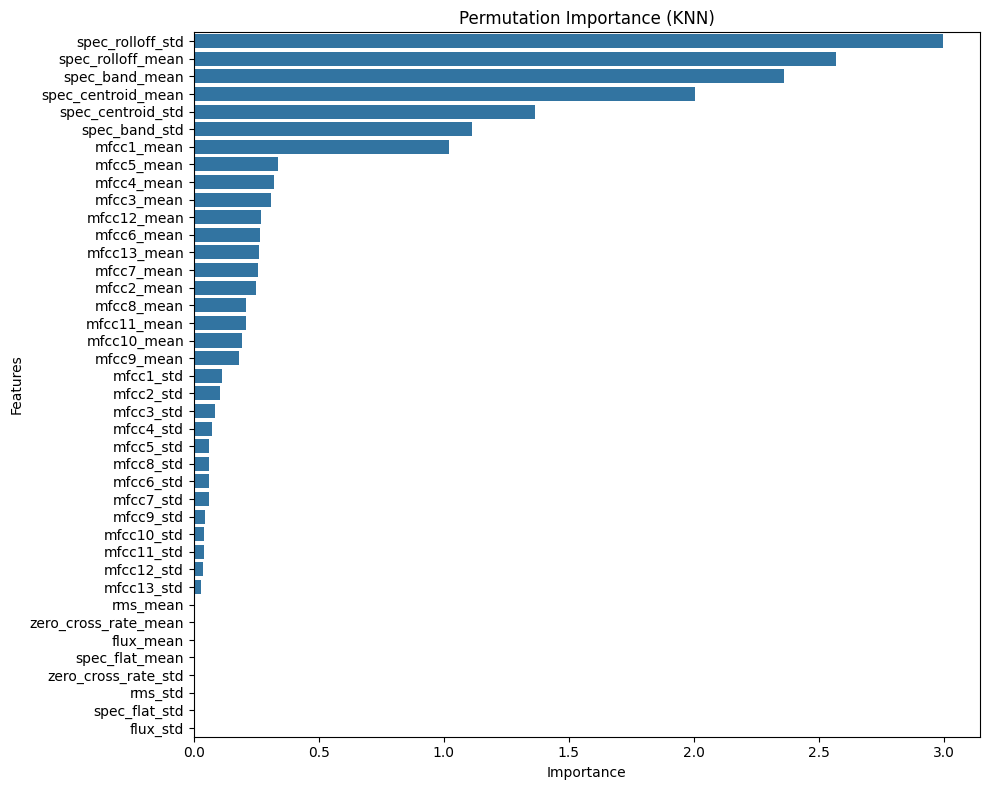

In [64]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

'''Principe :

On mesure la performance du modèle

On mélange une feature

On regarde combien la performance chute

Si elle chute beaucoup → feature importante.'''


# Permutation importance
result = permutation_importance(
    model_KNN,
    X,
    y,
    n_repeats=20,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importances = result.importances_mean
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,8))

sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)
print(train_KNN.score(X_test, y_test))

plt.title("Permutation Importance (KNN)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [65]:
import pandas as pd
import plotly.express as px

# Charger les données
df = pd.read_csv("calibration_sounds_features.csv", sep=",")

# Bornes des plages
bins = [0, 4, 8, 12, 16, 20]
labels = ["0-4mls", "4-8mls", "8-12mls", "12-16mls", "16-20mls"]

# Variable catégorielle
df["debit_range"] = pd.cut(
    df["debit"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Couleurs personnalisées (contrastées)
color_map = {
    "0-4mls": "blue",
    "4-8mls": "green",
    "8-12mls": "red",
    "12-16mls": "black",
    "16-20mls": "orange"   # 5e classe (si tu veux on peut aussi la garder rouge foncé)
}

# Scatter interactif
fig = px.scatter(
    df,
    x="spec_rolloff_std",
    y="spec_rolloff_mean",
    color="debit_range",
    color_discrete_map=color_map,
    hover_data={
        "debit": True,
        "mfcc12_mean": True,
        "mfcc9_mean": True
    },
    title="Scatter plot spec_rolloff_std vs spec_rolloff_mean par plage de débit"
)

fig.show()


In [66]:
# KNN Regressor
from sklearn.metrics import mean_absolute_error

# Prédictions
y_pred = train_KNN.predict(X_test)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print("tableaux de comparaison des données de test échnantillon")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_test, y_pred), 2)
print("MAE:", mae)

y_pred_real = model_KNN.predict(X_real) # on prend le modèle entrainé sur tout le dataset de calibration pour les prédictions réelles
# y_pred_real = train_KNN.predict(X_real)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_real": y_real.values,
    "y_pred": y_pred_real
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_real"] - comparaison["y_pred"])

print("tableaux de comparaison des données de mesures réelles")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_real, y_pred_real), 2)
print("MAE:", mae)

tableaux de comparaison des données de test échnantillon
   y_test     y_pred    erreur
0  11.834  17.159178  5.325178
1  11.013  14.490308  3.477308
2   9.074  16.260162  7.186162
3  19.762  17.080618  2.681382
4  25.380  20.197404  5.182596
5  15.105  11.706907  3.398093
6   9.099  10.718923  1.619923
7  15.354  15.327407  0.026593
MAE: 3.61
tableaux de comparaison des données de mesures réelles
   y_real     y_pred    erreur
0   8.930  17.103572  8.173572
1   9.290  11.453751  2.163751
2  10.090  17.292378  7.202378
3  11.049  16.293568  5.244568
4  11.120  11.453718  0.333718
5  11.760  16.277885  4.517885
6  12.500  16.294490  3.794490
7  18.650  16.307058  2.342942
8  21.270  16.293021  4.976979
MAE: 4.31


# Random Forest

0.9060854468387765


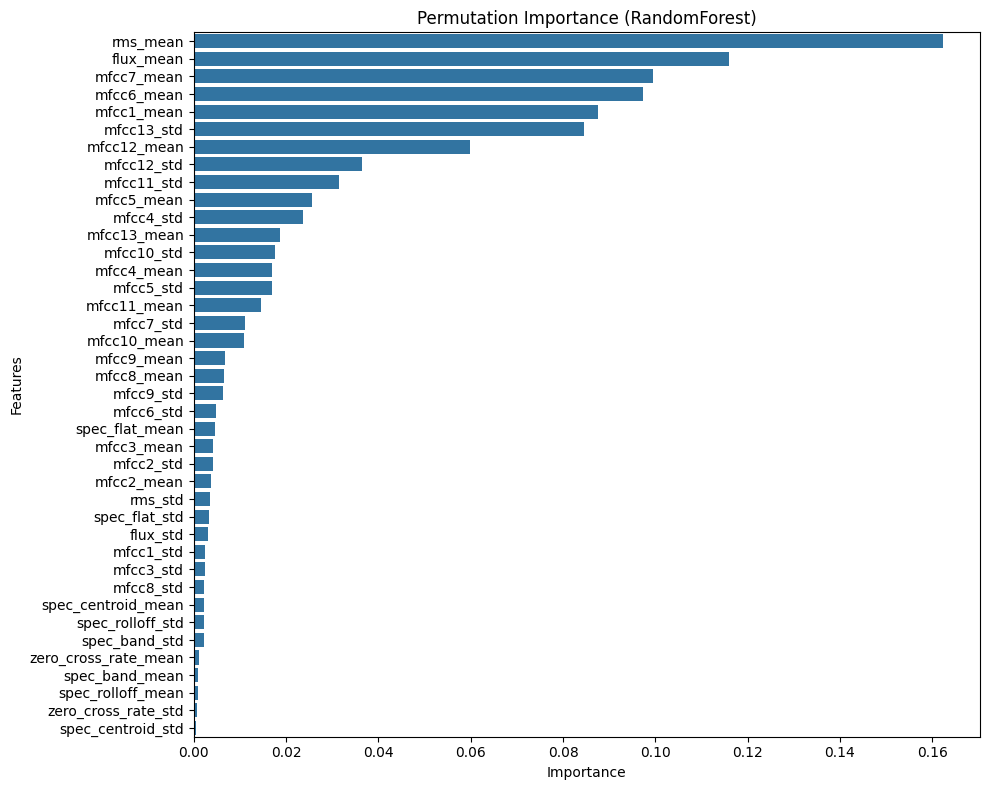

In [67]:
# Random Forest

# model_rf, train_rf = load_rf_model()

importances = model_rf.feature_importances_

indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,8))

sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)
print(train_rf.score(X_test, y_test))

plt.title("Permutation Importance (RandomForest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [68]:
# Random forest regressor
from sklearn.metrics import mean_absolute_error

# Prédictions
y_pred = train_rf.predict(X_test)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print("tableaux de comparaison des données de test échnantillon")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_test, y_pred), 2)
print("MAE:", mae)

y_pred_real = model_rf.predict(X_real) # on prend le modèle entrainé sur tout le dataset de calibration pour les prédictions réelles
# y_pred_real = train_rf.predict(X_real)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_real": y_real.values,
    "y_pred": y_pred_real
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_real"] - comparaison["y_pred"])

print("tableaux de comparaison des données de mesures réelles")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_real, y_pred_real), 2)
print("MAE:", mae)

tableaux de comparaison des données de test échnantillon
   y_test    y_pred   erreur
0  11.834  12.23788  0.40388
1  11.013  12.19708  1.18408
2   9.074  11.44203  2.36803
3  19.762  19.42639  0.33561
4  25.380  21.83513  3.54487
5  15.105  15.52954  0.42454
6   9.099   8.07570  1.02330
7  15.354  15.12836  0.22564
MAE: 1.19
tableaux de comparaison des données de mesures réelles
   y_real    y_pred   erreur
0   8.930  10.97564  2.04564
1   9.290  11.13139  1.84139
2  10.090  13.41949  3.32949
3  11.049  11.35285  0.30385
4  11.120  11.16926  0.04926
5  11.760  10.97736  0.78264
6  12.500  12.05474  0.44526
7  18.650  14.36067  4.28933
8  21.270  13.51273  7.75727
MAE: 2.32


# Ridge Regression

R2 test : 0.9622379688728183


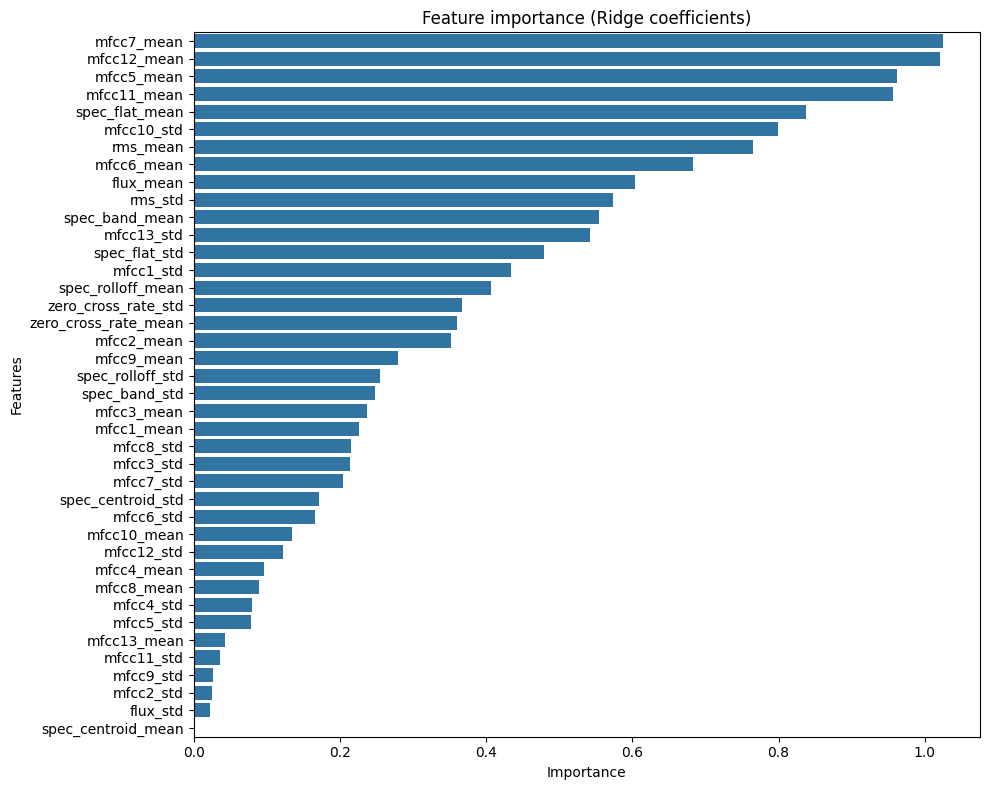

In [69]:

import matplotlib.pyplot as plt
import seaborn as sns


# Importance = valeur absolue des coefficients
importances = np.abs(model_ridge.coef_)

# Tri
indices = np.argsort(importances)[::-1]

# Score test
score = train_ridge.score(X_test_scaled, y_test)
print("R2 test :", score)

# Plot
plt.figure(figsize=(10,8))
sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)

plt.title("Feature importance (Ridge coefficients)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


In [70]:
# Ridge
from sklearn.metrics import mean_absolute_error

# Prédictions
y_pred = train_ridge.predict(X_test_scaled)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print("tableaux de comparaison des données de test échnantillon")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_test, y_pred), 2)
print("MAE:", mae)

y_pred_real = model_ridge.predict(X_test_real_scaled) # on prend le modèle entrainé sur tout le dataset de calibration pour les prédictions réelles
# y_pred_real = train_rf.predict(X_real)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_real": y_real.values,
    "y_pred": y_pred_real
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_real"] - comparaison["y_pred"])

print("tableaux de comparaison des données de mesures réelles")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_real, y_pred_real), 2)
print("MAE:", mae)

tableaux de comparaison des données de test échnantillon
   y_test     y_pred    erreur
0  11.834  13.719638  1.885638
1  11.013  11.867717  0.854717
2   9.074  10.084727  1.010727
3  19.762  18.733121  1.028879
4  25.380  23.993620  1.386380
5  15.105  15.347424  0.242424
6   9.099   9.471102  0.372102
7  15.354  15.251828  0.102172
MAE: 0.86
tableaux de comparaison des données de mesures réelles
   y_real     y_pred    erreur
0   8.930  10.617699  1.687699
1   9.290  14.243653  4.953653
2  10.090  11.855170  1.765170
3  11.049  14.143444  3.094444
4  11.120  14.078820  2.958820
5  11.760  11.843091  0.083091
6  12.500  14.431262  1.931262
7  18.650  14.163603  4.486397
8  21.270  13.008910  8.261090
MAE: 3.25


# Lasso Regression

R2 test : 0.9953287099396526


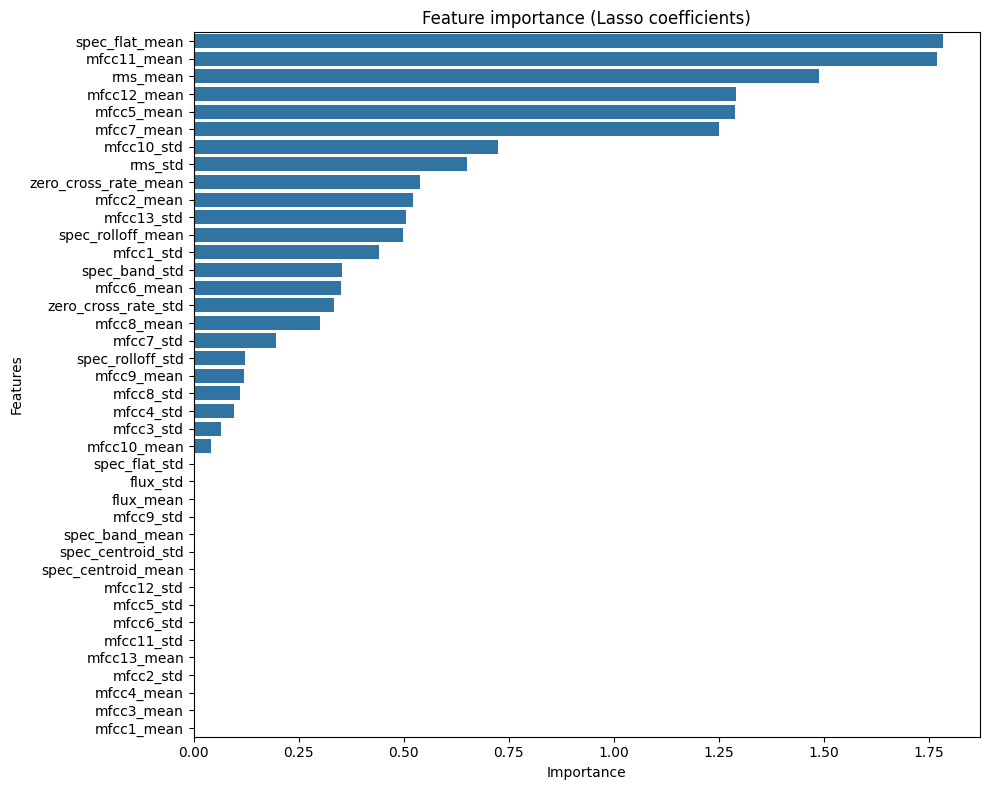

In [71]:


import matplotlib.pyplot as plt
import seaborn as sns



# Importance = valeur absolue des coefficients
importances = np.abs(model_lasso.coef_)

# Tri
indices = np.argsort(importances)[::-1]

# Score test
score = model_lasso.score(X_test_scaled, y_test)
print("R2 test :", score)

# Plot
plt.figure(figsize=(10,8))
sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)

plt.title("Feature importance (Lasso coefficients)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Features sélectionnées par Lasso
selected_features = calib.columns[:-1][model_lasso.coef_ != 0]
# print("Features retenues par Lasso :")
# print(selected_features)


In [72]:
# Ridge
from sklearn.metrics import mean_absolute_error

# Prédictions
y_pred = train_lasso.predict(X_test_scaled)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print("tableaux de comparaison des données de test échnantillon")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_test, y_pred), 2)
print("MAE:", mae)

y_pred_real = model_lasso.predict(X_test_real_scaled) # on prend le modèle entrainé sur tout le dataset de calibration pour les prédictions réelles
# y_pred_real = train_rf.predict(X_real)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_real": y_real.values,
    "y_pred": y_pred_real
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_real"] - comparaison["y_pred"])

print("tableaux de comparaison des données de mesures réelles")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_real, y_pred_real), 2)
print("MAE:", mae)

tableaux de comparaison des données de test échnantillon
   y_test     y_pred    erreur
0  11.834  12.762265  0.928265
1  11.013  11.469635  0.456635
2   9.074   8.212617  0.861383
3  19.762  18.793164  0.968836
4  25.380  24.035772  1.344228
5  15.105  14.611227  0.493773
6   9.099   7.770193  1.328807
7  15.354  16.195807  0.841807
MAE: 0.9
tableaux de comparaison des données de mesures réelles
   y_real     y_pred    erreur
0   8.930  10.640127  1.710127
1   9.290   7.898516  1.391484
2  10.090  11.318695  1.228695
3  11.049  19.176332  8.127332
4  11.120   7.337761  3.782239
5  11.760  15.630846  3.870846
6  12.500  15.819713  3.319713
7  18.650  13.009937  5.640063
8  21.270  11.584523  9.685477
MAE: 4.31


Rappel : qu’est-ce que mfcc7_mean ?

Les MFCC (Mel-Frequency Cepstral Coefficients) décrivent :

la forme du spectre

la structure fréquentielle globale

le “timbre” du signal

mfcc7_mean = moyenne temporelle du 7ᵉ coefficient.

👉 Donc c’est une information spectrale compressée.

Si le débit influence :

    la pression

    la turbulence

    le bruit généré

    la répartition énergétique dans le spectre

Alors il est plausible qu’un MFCC soit corrélé au débit.

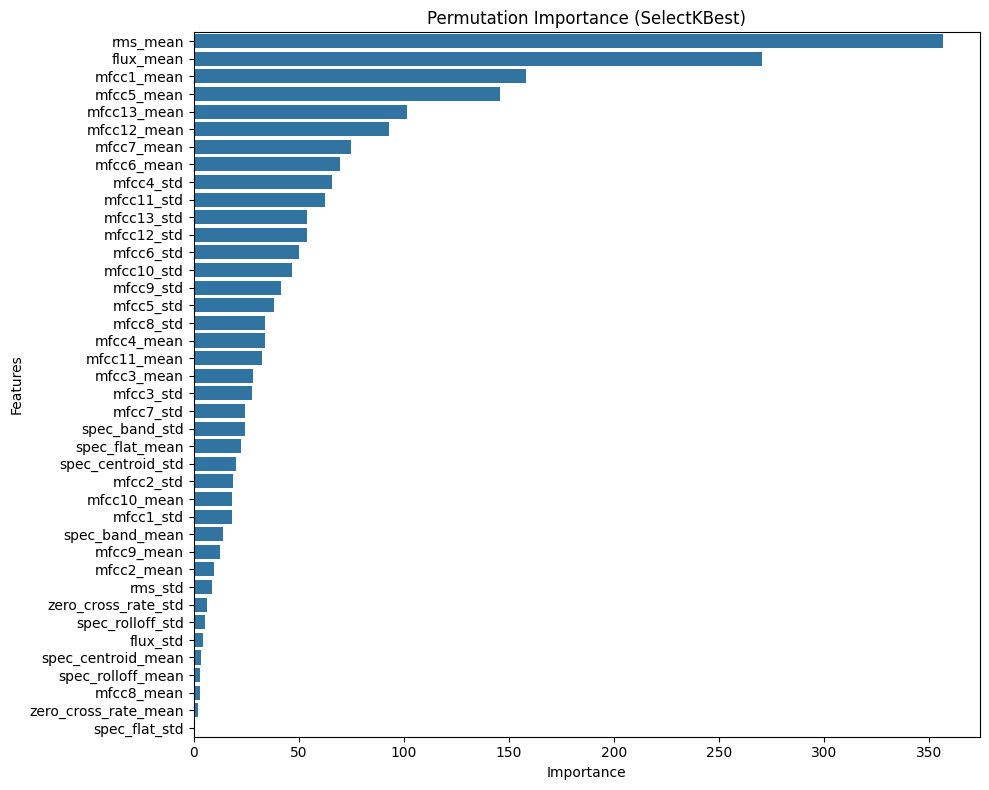

In [73]:
from sklearn.feature_selection import SelectKBest, f_regression

# mesure corrélation linéaire uniquement!!

selector = SelectKBest(score_func=f_regression, k="all")
selector.fit(X, y)


importances = selector.scores_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,8))

sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)

plt.title("Permutation Importance (SelectKBest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## Estimate Flow for a Segment

In [74]:
def estimate_flow(feat, model):
    """
    feat : vecteur features 1D (35 features par ex.)
    model : modèle KNeighborsRegressor déjà entraîné
    """
    
    feat = np.array(feat).reshape(1, -1)  # nécessaire pour sklearn
    prediction = model.predict(feat)

    return prediction[0]


## Analyze a Real Recording

In [75]:
def analyze_recording(file_path, nn, y_calib):
    y, sr = librosa.load(file_path, sr=32000)
    segments, frame_len = segment_audio(y, sr)

    results = []

    for i, (s, e) in enumerate(segments):
        seg = y[s*frame_len:e*frame_len]
        feat = extract_features(seg, sr)
        debit = estimate_flow(feat, nn, y_calib)
        duration = (e - s) * 0.2
        results.append({"phase": i+1, "debit": debit, "duree": duration})

    return results


## Plot Uroflow Curve

In [76]:
def plot_uroflow(results):
    times = []
    flows = []
    t = 0

    for r in results:
        times.append(t)
        flows.append(r['debit'])
        t += r['duree']

    plt.step(times, flows)
    plt.xlabel('Time (s)')
    plt.ylabel('Flow (ml/s)')
    plt.title('Estimated Uroflow Curve')
    plt.show()


# preprocessing mobile phone recording
        enregistrement smartphone
                ↓
        détection du jet
                ↓
        correction AGC
                ↓
        normalisation multi-appareils (robustesse téléphone)
                ↓
        extraction features librosa
                ↓
        modèle ML débit


Pipeline complet recommandé pour ton projet:

        file1 = preprocess_uroflow_audio("raw.wav", "step1.wav")

        file2 = device_normalization_wav(file1, "step2.wav")

        audio, sr = librosa.load(file2, sr=None)

        features = extract_features(audio, sr)

In [77]:
import numpy as np
import librosa
import soundfile as sf

def preprocess_uroflow_calibration(
    input_wav,                # chemin complet du fichier .wav enregistré avec le smartphone
    output_wav,               # chemin du fichier .wav corrigé exporté
    target_sr=None,           # 22050 fréquence cible pour homogénéiser les enregistrements. None = garde la fréquence native du téléphone en général 16kHz. 
    frame_length=2048,        # taille fenêtre analyse RMS
    hop_length=512,           # pas entre fenêtres RMS
    agc_sensitivity=2.5,      # sensibilité détection AGC smartphone
    agc_gain_limit=2.0        # gain maximum appliqué lors de la correction AGC
):
    """
    Version simplifiée du preprocessing pour enregistrements de calibration.

    Pipeline :
    1. Chargement audio
    2. Détection AGC smartphone
    3. Correction AGC immédiate mais limitée
    4. Normalisation multi-device
    5. Export WAV final

    Cette version ne modifie pas la structure temporelle du signal.
    """

    # -------------------------
    # 1. Chargement audio
    # -------------------------
    y, sr = librosa.load(input_wav, sr=target_sr, mono=True)

    # -------------------------
    # 2. Analyse RMS du signal
    # -------------------------
    rms = librosa.feature.rms(
        y=y,
        frame_length=frame_length,
        hop_length=hop_length
    )[0]

    diff = np.diff(rms)

    # seuil dynamique de détection AGC
    agc_threshold = -np.std(diff) * agc_sensitivity
    agc_candidates = np.where(diff < agc_threshold)[0]

    agc_frame = None

    # validation chute AGC réelle
    for c in agc_candidates:
        if c > 10 and c + 10 < len(rms):
            pre = np.mean(rms[c-10:c])
            post = np.mean(rms[c:c+10])

            # chute importante d'énergie
            if post < pre * 0.6:
                agc_frame = c
                break

    # -------------------------
    # 3. Correction AGC
    # -------------------------
    if agc_frame is not None:
        agc_sample = agc_frame * hop_length

        pre_rms = np.mean(rms[max(0, agc_frame - 20):agc_frame])
        post_rms = np.mean(rms[agc_frame:agc_frame + 20])

        if post_rms > 0:
            gain = pre_rms / post_rms
            gain = min(gain, agc_gain_limit)

            # correction immédiate
            y[agc_sample:] = y[agc_sample:] * gain

    # -------------------------
    # 4. Normalisation multi-device
    # -------------------------
    rms_global = np.sqrt(np.mean(y**2)) + 1e-8
    y = y / rms_global

    percentile_95 = np.percentile(np.abs(y), 95)
    y = y / (percentile_95 + 1e-8)

    y = np.clip(y, -1, 1)

    # -------------------------
    # 5. Export WAV
    # -------------------------
    sf.write(output_wav, y, sr)

    print("Calibration audio preprocess terminé")
    print("AGC détecté :", agc_frame is not None)
    print("Durée :", len(y) / sr, "secondes")

    return output_wav

In [79]:
preprocess_uroflow_calibration(
    "../20_fev/A51/15.331_mls_A51.wav",
    "../20_fev/A51/15.331_mls_A51_corrected.wav"
)

/tmp/ipykernel_198092/2422251120.py:30: UserWarning:

PySoundFile failed. Trying audioread instead.

/home/ed_st/.pyenv/versions/Artefact/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning:

librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.



FileNotFoundError: [Errno 2] No such file or directory: '../20_fev/A51/15.331_mls_A51.wav'

# Fonction : normalisation acoustique multi-téléphones

In [ ]:
import numpy as np
import librosa
import soundfile as sf


def device_normalization_wav(
    input_wav,
    output_wav="normalized.wav",
    n_fft=2048,
    hop_length=512,
    strength=0.8
):
    """
    Réduit la signature acoustique spécifique au téléphone
    tout en conservant les caractéristiques utiles pour le ML.
    """

    audio, sr = librosa.load(input_wav, sr=None, mono=True)

    # STFT
    S_complex = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    S_mag = np.abs(S_complex)
    phase = np.angle(S_complex)

    # profil spectral moyen du téléphone
    spectral_profile = np.mean(S_mag, axis=1, keepdims=True)

    spectral_profile += 1e-8

    # normalisation partielle (évite d'écraser l'information utile)
    S_mag_norm = S_mag / (spectral_profile ** strength)

    # reconstruction
    S_new = S_mag_norm * np.exp(1j * phase)
    audio_norm = librosa.istft(S_new, hop_length=hop_length)

    # normalisation amplitude finale
    audio_norm = audio_norm / np.max(np.abs(audio_norm)) * 0.9

    sf.write(output_wav, audio_norm, sr)

    return output_wav

# pipeline complet pour la mesure du débit d'un fluex réel de miction à partir d'un enregistrement smartphone:


        téléphone → enregistrement
                ↓
        preprocess_uroflow_audio ("raw.wav", "step1.wav") --> correction AGC + détection du jet ("step2.wav")
                ↓
        wav nettoyé
                ↓
        features 0.2 s
                ↓
        modèle débit
                ↓
        courbe uroflow

In [ ]:
import numpy as np
import librosa
import soundfile as sf
'''
Principes utilisés dans ce code :

    Détection automatique du jet par analyse RMS dynamique

    Découpe intelligente (pas basée sur 0,2 s mais sur le signal réel)

    Correction AGC (détection chute d’énergie progressive)

    Normalisation multi-téléphones

    Préservation des variations rapides (important pour tes fenêtres 0,2 s)

    Export d’un nouveau WAV prêt pour ton extraction de features

La découpe ne doit pas être faite sur 0,2 s ici — c’est mieux de le faire après
'''



def preprocess_uroflow_audio(
    input_wav,                # chemin complet du fichier .wav d'entrée
    output_wav,               # chemin du nouveau fichier .wav exporté
    target_sr=None,           # fréquence d'échantillonnage cible (uniformise tous les téléphones)# 22050 fréquence cible pour homogénéiser les enregistrements. None = garde la fréquence native du téléphone en général 16kHz. 
    frame_length=2048,        # taille de fenêtre pour analyse RMS (stabilité énergie)
    hop_length=512,           # pas entre fenêtres RMS
    max_internal_silence=0.5, # durée max silence interne conservé (secondes)
    top_db=30,                # seuil de suppression silence début/fin
    agc_sensitivity=2.5,      # sensibilité détection AGC (plus grand = détection plus stricte)
    agc_gain_limit=2.0        # gain maximum autorisé lors de la correction AGC
):
    """
    Préprocessing audio pour uroflow acoustique.

    Pipeline :
    1. Chargement audio
    2. Suppression silence début/fin
    3. Détection automatique du jet
    4. Détection AGC smartphone
    5. Correction AGC immédiate mais limitée
    6. Normalisation multi-device
    7. Gestion des silences internes (sans supprimer les zones AGC)
    8. Export WAV final
    """

    # -------------------------
    # 1. Chargement audio
    # -------------------------
    y, sr = librosa.load(input_wav, sr=target_sr, mono=True)

    # -------------------------
    # 2. Suppression silence début/fin
    # -------------------------
    y_trimmed, _ = librosa.effects.trim(y, top_db=top_db)

    # -------------------------
    # 3. Détection du jet
    # -------------------------
    rms = librosa.feature.rms(
        y=y_trimmed,
        frame_length=frame_length,
        hop_length=hop_length
    )[0]

    # estimation bruit de fond
    noise_floor = np.percentile(rms, 20)

    # seuil jet
    jet_threshold = noise_floor * 3

    jet_frames = np.where(rms > jet_threshold)[0]

    if len(jet_frames) == 0:
        print("Jet non détecté")
        return None

    start_frame = jet_frames[0]
    end_frame = jet_frames[-1]

    start_sample = start_frame * hop_length
    end_sample = end_frame * hop_length

    y = y_trimmed[start_sample:end_sample]

    # -------------------------
    # 4. Détection AGC smartphone
    # -------------------------
    rms2 = librosa.feature.rms(
        y=y,
        frame_length=frame_length,
        hop_length=hop_length
    )[0]

    diff = np.diff(rms2)

    # seuil AGC basé sur variabilité du signal
    agc_threshold = -np.std(diff) * agc_sensitivity

    agc_candidates = np.where(diff < agc_threshold)[0]

    agc_frame = None

    # vérifier que la chute est réelle et durable
    for c in agc_candidates:
        if c > 10 and c + 10 < len(rms2):
            pre = np.mean(rms2[c-10:c])
            post = np.mean(rms2[c:c+10])

            # vraie chute AGC
            if post < pre * 0.6:
                agc_frame = c
                break

    # -------------------------
    # 5. Correction AGC immédiate
    # -------------------------
    if agc_frame is not None:
        agc_sample = agc_frame * hop_length

        pre_rms = np.mean(rms2[max(0, agc_frame - 20):agc_frame])
        post_rms = np.mean(rms2[agc_frame:agc_frame + 20])

        if post_rms > 0:
            gain = pre_rms / post_rms
            gain = min(gain, agc_gain_limit)

            y[agc_sample:] = y[agc_sample:] * gain

    # -------------------------
    # 6. Normalisation multi-device
    # -------------------------
    rms_global = np.sqrt(np.mean(y**2)) + 1e-8
    y = y / rms_global

    percentile_95 = np.percentile(np.abs(y), 95)
    y = y / (percentile_95 + 1e-8)

    y = np.clip(y, -1, 1)

    # -------------------------
    # 7. Gestion silences internes
    # IMPORTANT : ne pas confondre AGC avec silence
    # -------------------------
    silence_threshold = noise_floor * 1.2

    rms3 = librosa.feature.rms(
        y=y,
        frame_length=frame_length,
        hop_length=hop_length
    )[0]

    max_silence_frames = int((max_internal_silence * sr) / hop_length)

    mask = rms3 > silence_threshold

    silence_len = 0
    new_mask = np.zeros_like(mask)

    for i, m in enumerate(mask):
        if m:
            silence_len = 0
            new_mask[i] = 1
        else:
            silence_len += 1
            if silence_len <= max_silence_frames:
                new_mask[i] = 1
            else:
                new_mask[i] = 0

    # reconstruction signal
    y_frames = librosa.util.frame(
        y,
        frame_length=hop_length,
        hop_length=hop_length
    ).T

    y_filtered = y_frames[new_mask].flatten()

    # -------------------------
    # 8. Export final
    # -------------------------
    sf.write(output_wav, y_filtered, sr)

    print("Audio preprocess terminé")
    print("AGC détecté :", agc_frame is not None)
    print("Durée finale :", len(y_filtered) / sr, "secondes")

    return output_wav